## Myntra Women's Dresses — Pricing & Discount Analysis

I scraped around 3,000 women's dress listings from Myntra every day for 20 days, across three different sort modes: Popularity, Discount, and Recommended. Each sort mode represents a different thing Myntra is trying to surface, and I wanted to see whether that actually shows up in the data.

The dataset ended up with about 54,000 rows and 30 columns covering price, MRP, discount, ratings, inventory, and a few platform-specific fields like promotion tags and delivery promises.

The main thing I was trying to understand is whether the discounting on this platform is genuine or manufactured. At 72% median discount across the entire category, something is clearly off, and I wanted to trace exactly what.

**Dataset:** ~54,000 product snapshots over 20 days, Jan 12 to Jan 31 2026  
**Category:** Women's Dresses  
**Sort modes scraped:** Popularity, Discount, Recommended

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from glob import glob

In [ ]:
# load all 20 days across all three sort types
df = pd.concat((pd.read_csv(f) for f in glob("../data/raw/*")), ignore_index=True)

# remove rows where the same product was scraped more than once on the same day
# (can happen when a product appears in multiple sort files for that date)
df = df.drop_duplicates(subset=['product_id', 'snapshot_date'], keep='first')

print('Shape: ', df.shape)
print('Source sort distribution:')
print(df['source_sort'].value_counts())


Shape:  (53904, 30)
Source sort distribution:
source_sort
discount       19698
popularity     17830
recommended    16376
Name: count, dtype: int64


#### Data Preparation

Type conversions, derived columns, and a few bucketing decisions.

In [ ]:
#convert to datetime format
df['snapshot_date'] = pd.to_datetime(df['snapshot_date'])

for col in ["mrp", "price", "discount", "rating", "rating_count"]:
    df[col] = pd.to_numeric(df[col], errors='coerce')

#calc discount % off
df['discount_pct'] = (100*(df['mrp']-df['price'])/df['mrp']).round(2)

#how far current price is from product's all time lowest price
df['price_to_best_gap_pct'] = (100*(df['price']-df['best_price'])/df['price']).round(2)

df['is_available'] = df['available'].astype(str).str.lower().isin(['true', 1, 'yes'])

#create price tier bucket 
df['price_tier'] = pd.cut(df['price'], 
                          bins=[0,500,1000,2000,5000,10000], 
                          labels=['Budget(<500)', 'Low-Mid(500-1k)', 'Mid(1k-2k)', 'Premium(2k-5k)', 'Luxury(5k+)'])

#how many unique days eac product appears in the dataset
df['days_present'] = df.groupby('product_id')['snapshot_date'].transform('nunique')

## continuity cohort: transient products vs stable platform fixtures
df['continuity_cohort'] = pd.cut(
    df['days_present'],
    bins=[0,4,9,14,20],
    labels=['Transient (1-4d)', 'Short (5-9d)', 'Medium (10-14d)', 'Stable (15-20d)'])



### 1. How Deep Are the Discounts?

Before proceeding further I wanted to understand how steep the discounts are.
Typically a median discount of 20–30% would indicate standard promotional activity but the pattern here turned out to be quite different.

In [ ]:
#keeping only valid discount rows
df = df[df['discount_pct'].notna()]

print("Prep done. Discount % range:")
print(df['discount_pct'].describe().round(2))

Prep done. Discount % range:
count    53904.00
mean        70.16
std         20.01
min          0.00
25%         60.02
50%         72.02
75%         88.26
max         90.05
Name: discount_pct, dtype: float64


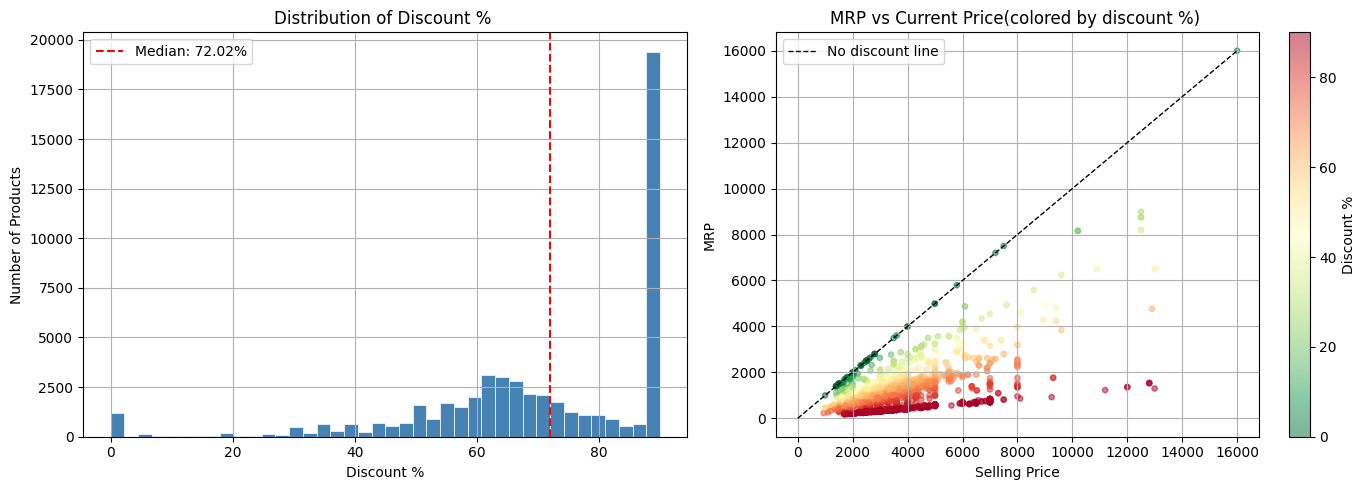

Median discount: 72.02%
Products with >70% discount: 28650 (53.2%)


In [ ]:
#plotting histogram and scatter plot
fig, axes = plt.subplots(1,2, figsize=(14,5))

#distribution of discount % usign histogram
axes[0].hist(df['discount_pct'], bins=40, linewidth=0.5, color='steelblue', edgecolor='white')
axes[0].axvline(df['discount_pct'].median(), linestyle='--', color='red',
                label=f'Median: {df['discount_pct'].median()}%')
axes[0].set_title('Distribution of Discount % ')
axes[0].set_xlabel('Discount %')
axes[0].set_ylabel('Number of Products')
axes[0].grid(True)
axes[0].legend()

#MRP vs current price scatter plot(taking sample to avoid overplotting)
sample = df[['mrp', 'price', 'discount_pct']].dropna().sample(2000, random_state=42)
scatter = axes[1].scatter(sample['mrp'], sample['price'], c=sample['discount_pct'], 
                          cmap='RdYlGn_r', s=15, alpha=0.5)
maxval = max(sample['price'].max(), sample['mrp'].max())
axes[1].plot([0, maxval], [0,maxval], 'k--', linewidth=1, label='No discount line')
plt.colorbar(scatter, ax=axes[1], label='Discount %') 
axes[1].set_title('MRP vs Current Price(colored by discount %) ')
axes[1].set_xlabel('Selling Price')
axes[1].set_ylabel('MRP')
axes[1].grid(True)
axes[1].legend()

plt.tight_layout()
plt.show()

print (f'Median discount: {df['discount_pct'].median()}%')
print (f'Products with >70% discount: {(df['discount_pct']>70).sum()} ({(df['discount_pct']>70).mean()*100:.1f}%)')

Median discount is 72% and over 53% of products are discounted more than 70% off MRP. This does not look like a sale, it looks like the default pricing model for this category. The MRP on most of these listings is not a real price anyone was ever expected to pay.

### 2. Which Brands Actually Discount vs Which Fake It

Not all discounting is the same. Some brands set a genuine high price and run real promotions. Others set an inflated MRP purely to display a large discount number. The positioning map below separates these two groups clearly.

In [ ]:
#brands with 100+ appearances
brand_counts = df['brand'].value_counts()
top_brands = brand_counts[brand_counts>=100].index.tolist()
#filtering data for top brands only
df_brands = df[df['brand'].isin(top_brands)].copy()

print('Brands with 100+ appearances: ', len(top_brands))
print('Rows in filtered dataset: ', len(df_brands))

Brands with 100+ appearances:  101
Rows in filtered dataset:  45737


In [ ]:
brand_summary = df_brands.groupby('brand').agg(avg_mrp=('mrp', 'mean'),
                                               avg_price=('price', 'mean'),
                                               avg_discount_pct=('discount_pct', 'mean'),
                                               median_discount_pct=('discount_pct', 'median'),
                                               avg_price_to_best_gap=('price_to_best_gap_pct', 'mean'),
                                               avg_rating=('rating', 'mean'),
                                               total_products=('product_id', 'nunique'),
                                               coupon_usage=('coupon_discount', lambda x:x.notna().mean()*100)
                                               ).round(2).reset_index()

brand_summary = brand_summary.sort_values('avg_discount_pct', ascending=False)

print('Top 10 highest discounted brands')
print(brand_summary.head(10)[['brand','avg_mrp','avg_price','avg_discount_pct','avg_rating']])

Top 10 highest discounted brands
                brand  avg_mrp  avg_price  avg_discount_pct  avg_rating
28         FLAMBOYANT  3358.00     347.44             89.67        1.76
23            DRESOUL  9326.85     969.91             89.57        2.34
72           STYLENZA  6999.00     749.74             89.29        0.00
89              VASVI  5032.75     544.36             89.22        2.39
17         Chandbaali  5831.39     635.46             89.09        0.61
61          RAJGRANTH  5136.66     562.49             89.06        3.94
0             Amagyaa  3700.35     409.56             88.97        2.03
64              S.K.C  6999.00     786.21             88.77        0.00
78  Stylecast X Kotty  2991.27     335.61             88.75        3.11
16             Cation  2978.92     333.19             88.73        1.35


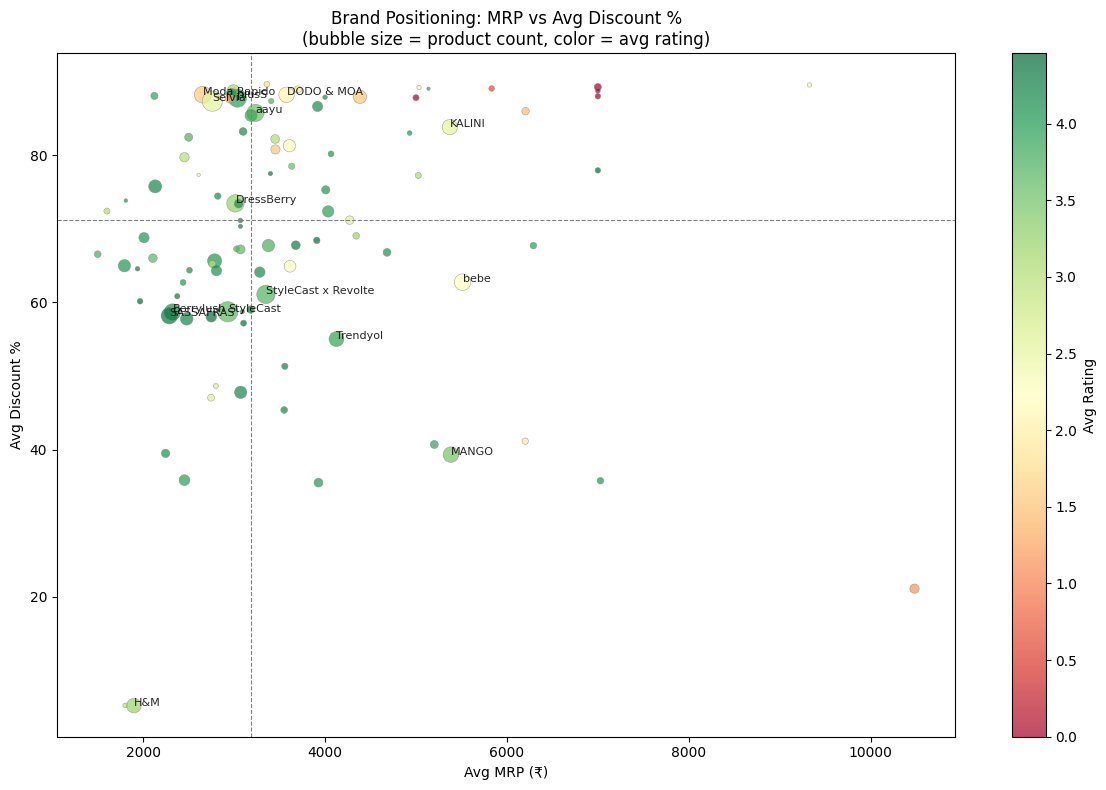

In [ ]:
#Brand positioning map : Avg MRP vs Avg Discount %

plt.figure(figsize=(12,8))
scatter = plt.scatter(brand_summary['avg_mrp'], brand_summary['avg_discount_pct'], 
            c=brand_summary['avg_rating'], cmap='RdYlGn', 
            s=brand_summary['total_products'], alpha=0.7,
            linewidth=0.4, edgecolors='grey')

plt.colorbar(scatter, label='Avg Rating')

#label top brands
for _, row in brand_summary.nlargest(15, 'total_products').iterrows():
    plt.annotate(row['brand'], xy=(row['avg_mrp'], row['avg_discount_pct']),
                 fontsize=8, alpha=0.85)
    
#quadrant median lines
plt.axhline(brand_summary['avg_discount_pct'].median(), color='grey', linestyle='--', linewidth=0.8)
plt.axvline(brand_summary['avg_mrp'].median(), color='grey', linestyle='--', linewidth=0.8)

plt.title('Brand Positioning: MRP vs Avg Discount %\n(bubble size = product count, color = avg rating)')
plt.xlabel('Avg MRP (₹)')
plt.ylabel('Avg Discount %')
plt.tight_layout()
plt.show()

Top 10 highest-discount brands average 89% off MRP but ratings between 0 and 3.9. The top cluster in the scatter chart is entirely orange and red bubbles, showing poor ratings regardless of MRP level. These brands set artificially high MRPs so the label shows a huge discount, but the actual transaction price is Rs 350 to Rs 970. H&M sits alone in the bottom-left corner at around 7% discount with honest pricing and strong ratings. MANGO and Biba sit further right with moderate discounts off genuine MRPs. The two pricing philosophies are visually separated.

### 3. Does Myntra's Sort Mode Mean Anything?

Myntra surfaces products through three different sort modes. I wanted to check whether these modes actually differ in the kind of product they show, or whether they're all drawing from the same pool.

/tmp/ipykernel_22110/3244791816.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=rated, x='source_sort', y='discount_pct',
/tmp/ipykernel_22110/3244791816.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=rated, x='source_sort', y='rating',


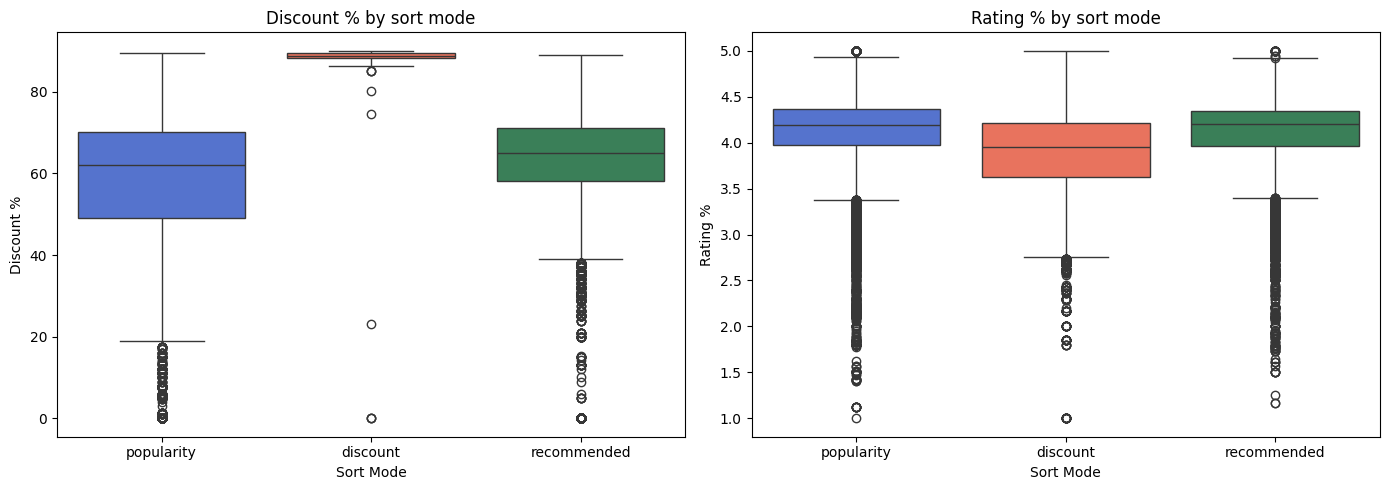

,avg_discount_pct,median_discount_pct,avg_rating,avg_rating_count,avg_mrp,avg_price
source_sort,,,,,,
discount,88.76,88.65,2.25,106.73,3770.77,423.14
popularity,56.43,61.01,3.68,982.86,3890.62,1720.41
recommended,62.74,65.01,3.88,1332.76,2749.57,963.21


In [ ]:
import seaborn as sns

sort_order = ['popularity', 'discount', 'recommended']
palette = {'popularity': 'royalblue', 'discount': 'tomato', 'recommended': 'seagreen'}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

#discount % by sort mode
rated = df[df['rating']>0]
sns.boxplot(data=rated, x='source_sort', y='discount_pct',
            order=sort_order, palette=palette, ax=axes[0])
axes[0].set_title('Discount % by sort mode')
axes[0].set_xlabel('Sort Mode')
axes[0].set_ylabel('Discount %')

#rating by sort mode
sns.boxplot(data=rated, x='source_sort', y='rating',
            order=sort_order, palette=palette, ax=axes[1])
axes[1].set_title('Rating % by sort mode')
axes[1].set_xlabel('Sort Mode')
axes[1].set_ylabel('Rating %')

plt.tight_layout()
plt.show()

#numerical summary
sort_summary = df.groupby('source_sort').agg(avg_discount_pct=('discount_pct', 'mean'),
                                             median_discount_pct=('discount_pct', 'median'),
                                             avg_rating=('rating', 'mean'),
                                             avg_rating_count=('rating_count', 'mean'),
                                             avg_mrp=('mrp', 'mean'),
                                             avg_price=('price', 'mean')).round(2)
                                             
sort_summary